# Homework 2: Phân loại Đa lớp với KNN, One-vs-Rest, và One-vs-One
## Môn học: Trí Tuệ Nhân Tạo - EE3063

Nhóm Thực Hiện: [Điền tên thành viên nhóm]

MSSV: [Điền MSSV thành viên nhóm]

Nội dung:
1. Giới thiệu bài toán phân loại đa lớp và tạo dữ liệu mẫu.
2. Xây dựng thuật toán K-Nearest Neighbors (KNN) từ đầu.
3. Xây dựng chiến lược One-vs-Rest (OvR) sử dụng Perceptron làm bộ phân loại cơ sở.
4. Xây dựng chiến lược One-vs-One (OvO) sử dụng Perceptron làm bộ phân loại cơ sở.
5. Áp dụng các thuật toán lên dữ liệu và đánh giá.

In [20]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import requests
import csv
from collections import Counter # Dùng để đếm số lần xuất hiện của các lớp trong KNN
from sklearn.model_selection import train_test_split # Dùng để chia dữ liệu
from sklearn.preprocessing import StandardScaler # Chuẩn hóa dữ liệu
from sklearn.datasets import make_blobs # Tạo dữ liệu mẫu có cụm


## 1. Giới thiệu

Bài toán phân loại đa lớp là một bài toán phổ biến trong học máy, nơi chúng ta cần gán một đối tượng vào một trong nhiều hơn hai lớp (categories). Ví dụ, nhận dạng chữ số (0-9), phân loại các loại hoa, v.v.

Trong bài tập này, chúng ta sẽ tự xây dựng và áp dụng ba phương pháp/thuật toán khác nhau để giải quyết bài toán phân loại đa lớp:
1.  **K-Nearest Neighbors (KNN):** Một thuật toán học có giám sát đơn giản, dựa trên việc tìm các điểm dữ liệu gần nhất.
2.  **One-vs-Rest (OvR) / One-vs-All (OvA):** Một chiến lược để sử dụng các bộ phân loại nhị phân (binary classifiers) cho bài toán đa lớp. Chúng ta sẽ sử dụng Perceptron (từ HW1) làm bộ phân loại nhị phân cơ sở.
3.  **One-vs-One (OvO):** Một chiến lược khác cũng sử dụng các bộ phân loại nhị phân cho bài toán đa lớp, cũng với Perceptron làm bộ phân loại cơ sở.

## 2. Tải và Tiền xử lý Dữ liệu

### 2.1. Tải Dữ liệu
Dữ liệu `audi.csv` chứa thông tin về các xe Audi đã qua sử dụng.

Các cột trong dataset: `model, year, price, transmission, mileage, fuelType, tax, mpg, engineSize`

In [28]:
# Tải dữ liệu
url = 'https://raw.githubusercontent.com/ntthang-dev/AI_Control_HCMUT_EE3063_Spring2025/main/datasets/audi.csv'
try:
    response = requests.get(url)
    response.raise_for_status() 
    data_lines = response.text.splitlines()
    reader = csv.reader(data_lines)
    header = next(reader)
    data_audi = list(reader)
    data_audi_np = np.array(data_audi)
    print(f"Tải thành công {len(data_audi)} mẫu dữ liệu (không tính header).")
    print(f"Header: {header}")
except requests.exceptions.RequestException as e:
    print(f"Lỗi khi tải dữ liệu: {e}")
    data_audi_np = np.array([]) 

Tải thành công 10668 mẫu dữ liệu (không tính header).
Header: ['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize']


### 2.2. Chọn Đặc Trưng và Tạo Biến Mục Tiêu

-   **Đặc trưng (Features - X):** Chúng ta sẽ chọn 3 đặc trưng số:
    1.  `year` (Năm sản xuất - index 1)
    2.  `mileage` (Số km đã đi - index 4)
    3.  `engineSize` (Kích thước động cơ - index 8)

-   **Biến Mục tiêu (Target - y):** Chúng ta cần tạo 3 lớp. Chúng ta sẽ tạo các lớp này bằng cách chia cột `price` (Giá xe - index 2) thành 3 khoảng (bins) dựa trên các phân vị (quantiles):
    * Lớp 0: Giá thấp (ví dụ: dưới phân vị 33.3%)
    * Lớp 1: Giá trung bình (ví dụ: từ phân vị 33.3% đến 66.6%)
    * Lớp 2: Giá cao (ví dụ: trên phân vị 66.6%)

In [29]:
if data_audi_np.size > 0:
    try:
        # Chọn các cột đặc trưng và chuyển sang float
        # year (index 1), mileage (index 4), engineSize (index 8)
        # price (index 2)
        X_features_audi = data_audi_np[:, [1, 4, 8]].astype(float) # Sửa tên biến
        prices_audi = data_audi_np[:, 2].astype(float) # Sửa tên biến

        # Tạo biến mục tiêu 3 lớp từ 'price'
        q1_audi = np.percentile(prices_audi, 33.3) # Sửa tên biến
        q2_audi = np.percentile(prices_audi, 66.6) # Sửa tên biến

        y_target_audi = np.zeros_like(prices_audi, dtype=int) # Sửa tên biến
        y_target_audi[prices_audi < q1_audi] = 0
        y_target_audi[(prices_audi >= q1_audi) & (prices_audi < q2_audi)] = 1
        y_target_audi[prices_audi >= q2_audi] = 2

        print(f"\nNgưỡng giá cho các lớp: q1={q1_audi:.2f}, q2={q2_audi:.2f}")
        print(f"Số lượng mẫu trong mỗi lớp: {Counter(y_target_audi)}")

        # Chuẩn hóa đặc trưng
        scaler_audi_hw2 = StandardScaler() # Đổi tên scaler để tránh trùng lặp nếu có ở notebook khác
        X_scaled_audi_hw2 = scaler_audi_hw2.fit_transform(X_features_audi) # Đổi tên biến

        # Chia dữ liệu
        X_train_audi, X_test_audi, y_train_audi, y_test_audi = train_test_split(
            X_scaled_audi_hw2, y_target_audi, test_size=0.3, random_state=42, stratify=y_target_audi
        )
        print(f"\nKích thước tập huấn luyện: X={X_train_audi.shape}, y={y_train_audi.shape}")
        print(f"Kích thước tập kiểm thử: X={X_test_audi.shape}, y={y_test_audi.shape}")

    except Exception as e:
        print(f"Lỗi khi xử lý dữ liệu: {e}")
        X_train_audi, X_test_audi, y_train_audi, y_test_audi = np.array([]), np.array([]), np.array([]), np.array([])
else:
    print("Không có dữ liệu để xử lý.")
    X_train_audi, X_test_audi, y_train_audi, y_test_audi = np.array([]), np.array([]), np.array([]), np.array([])


Ngưỡng giá cho các lớp: q1=16995.00, q2=24990.00
Số lượng mẫu trong mỗi lớp: Counter({np.int64(2): 3567, np.int64(1): 3552, np.int64(0): 3549})

Kích thước tập huấn luyện: X=(7467, 3), y=(7467,)
Kích thước tập kiểm thử: X=(3201, 3), y=(3201,)


## 3. Xây dựng các Thuật toán Phân loại

Chúng ta sẽ xây dựng các lớp Perceptron, KNNClassifier, OneVsRestClassifier, và OneVsOneClassifier.

In [31]:
# --- Lớp Perceptron (từ HW1) ---
class Perceptron:
    def __init__(self, n_iters=100):
        self.n_iters = n_iters; self.weights = None
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features + 1)
        X_b = np.concatenate([np.ones((n_samples, 1)), X], axis=1)
        y_transformed = np.array(y)
        for _ in range(self.n_iters):
            misclassified_count = 0
            for idx, x_i in enumerate(X_b):
                linear_output = np.dot(x_i, self.weights)
                y_predicted = 1 if linear_output >= 0 else 0
                update_needed = False
                if y_transformed[idx] == 1 and y_predicted == 0: self.weights += x_i; update_needed = True
                elif y_transformed[idx] == 0 and y_predicted == 1: self.weights -= x_i; update_needed = True
                if update_needed: misclassified_count += 1
            if misclassified_count == 0: break
        return self
    def decision_function(self, X):
        n_samples = X.shape[0]
        X_b = np.concatenate([np.ones((n_samples, 1)), X], axis=1)
        return np.dot(X_b, self.weights)
    def predict(self, X):
        return np.where(self.decision_function(X) >= 0, 1, 0)

# --- Lớp KNNClassifier ---
class KNNClassifier:
    def __init__(self, k=3):
        self.k = k; self.X_train = None; self.y_train = None
    def fit(self, X_train, y_train):
        self.X_train = X_train; self.y_train = y_train
    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2)**2))
    def predict_single(self, x_test):
        if self.X_train is None: raise ValueError("KNN chưa được huấn luyện.")
        distances = [self._euclidean_distance(x_test, xp) for xp in self.X_train]
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        return Counter(k_nearest_labels).most_common(1)[0][0]
    def predict(self, X_test):
        return np.array([self.predict_single(xt) for xt in X_test])

# --- Lớp OneVsRestClassifier ---
class OneVsRestClassifier:
    def __init__(self, base_classifier_constructor, n_iters_perceptron=100):
        self.base_classifier_constructor = base_classifier_constructor
        self.n_iters_perceptron = n_iters_perceptron
        self.classifiers = []; self.classes_ = None
    def fit(self, X_train, y_train):
        self.classes_ = np.unique(y_train); self.classifiers = []
        for cls_label in self.classes_:
            y_binary = np.where(y_train == cls_label, 1, 0)
            classifier = self.base_classifier_constructor(n_iters=self.n_iters_perceptron)
            classifier.fit(X_train, y_binary)
            self.classifiers.append(classifier)
        return self
    def predict(self, X_test):
        if not self.classifiers: raise ValueError("OvR chưa được huấn luyện.")
        decision_scores = np.array([clf.decision_function(X_test) for clf in self.classifiers]).T
        predicted_indices = np.argmax(decision_scores, axis=1)
        return self.classes_[predicted_indices]

# --- Lớp OneVsOneClassifier ---
class OneVsOneClassifier:
    def __init__(self, base_classifier_constructor, n_iters_perceptron=100):
        self.base_classifier_constructor = base_classifier_constructor
        self.n_iters_perceptron = n_iters_perceptron
        self.classifiers = []; self.class_pairs = []; self.classes_ = None
    def fit(self, X_train, y_train):
        self.classes_ = np.unique(y_train); n_classes = len(self.classes_)
        self.classifiers = []; self.class_pairs = []
        for i in range(n_classes):
            for j in range(i + 1, n_classes):
                cls1_label = self.classes_[i]; cls2_label = self.classes_[j]
                self.class_pairs.append((cls1_label, cls2_label))
                indices = np.where((y_train == cls1_label) | (y_train == cls2_label))
                X_pair = X_train[indices]; y_pair_original = y_train[indices]
                y_binary = np.where(y_pair_original == cls1_label, 1, 0)
                classifier = self.base_classifier_constructor(n_iters=self.n_iters_perceptron)
                classifier.fit(X_pair, y_binary)
                self.classifiers.append(classifier)
        return self
    def predict(self, X_test):
        if not self.classifiers: raise ValueError("OvO chưa được huấn luyện.")
        n_samples = X_test.shape[0]; n_classes = len(self.classes_)
        votes = np.zeros((n_samples, n_classes))
        for clf_idx, classifier in enumerate(self.classifiers):
            cls1_orig, cls2_orig = self.class_pairs[clf_idx]
            cls1_idx_map = np.where(self.classes_ == cls1_orig)[0][0]
            cls2_idx_map = np.where(self.classes_ == cls2_orig)[0][0]
            binary_preds = classifier.predict(X_test)
            for sample_idx in range(n_samples):
                if binary_preds[sample_idx] == 1: votes[sample_idx, cls1_idx_map] += 1
                else: votes[sample_idx, cls2_idx_map] += 1
        predicted_indices = np.argmax(votes, axis=1)
        return self.classes_[predicted_indices]

# --- Hàm tính Accuracy ---
def calculate_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

## 4. Huấn luyện và Đánh giá các Mô hình

In [32]:
if X_train_audi.size > 0 and X_test_audi.size > 0 :
    print("\n--- KNN Classifier ---")
    knn_audi = KNNClassifier(k=5)
    knn_audi.fit(X_train_audi, y_train_audi)
    y_pred_knn_audi = knn_audi.predict(X_test_audi)
    accuracy_knn_audi = calculate_accuracy(y_test_audi, y_pred_knn_audi)
    print(f"Độ chính xác (Accuracy) của KNN (k=5) trên Audi dataset (3 đặc trưng): {accuracy_knn_audi:.4f}")

    print("\n--- One-vs-Rest (Perceptron) ---")
    ovr_audi = OneVsRestClassifier(base_classifier_constructor=Perceptron, n_iters_perceptron=100)
    ovr_audi.fit(X_train_audi, y_train_audi)
    y_pred_ovr_audi = ovr_audi.predict(X_test_audi)
    accuracy_ovr_audi = calculate_accuracy(y_test_audi, y_pred_ovr_audi)
    print(f"Độ chính xác (Accuracy) của OvR (Perceptron) trên Audi dataset (3 đặc trưng): {accuracy_ovr_audi:.4f}")

    print("\n--- One-vs-One (Perceptron) ---")
    ovo_audi = OneVsOneClassifier(base_classifier_constructor=Perceptron, n_iters_perceptron=100)
    ovo_audi.fit(X_train_audi, y_train_audi)
    y_pred_ovo_audi = ovo_audi.predict(X_test_audi)
    accuracy_ovo_audi = calculate_accuracy(y_test_audi, y_pred_ovo_audi)
    print(f"Độ chính xác (Accuracy) của OvO (Perceptron) trên Audi dataset (3 đặc trưng): {accuracy_ovo_audi:.4f}")
else:
    print("Không đủ dữ liệu để huấn luyện và đánh giá các mô hình 3 đặc trưng.")


--- KNN Classifier ---
Độ chính xác (Accuracy) của KNN (k=5) trên Audi dataset (3 đặc trưng): 0.7894

--- One-vs-Rest (Perceptron) ---
Độ chính xác (Accuracy) của OvR (Perceptron) trên Audi dataset (3 đặc trưng): 0.6898

--- One-vs-One (Perceptron) ---
Độ chính xác (Accuracy) của OvO (Perceptron) trên Audi dataset (3 đặc trưng): 0.6810


## 5. Trực quan hóa Vùng Quyết định (sử dụng 2 đặc trưng)

Để trực quan hóa, chúng ta sẽ chọn 2 trong 3 đặc trưng (ví dụ: `year` và `mileage` sau khi chuẩn hóa),
huấn luyện lại các mô hình trên 2 đặc trưng này, và vẽ các vùng quyết định.


--- Trực quan hóa KNN (2 đặc trưng) ---


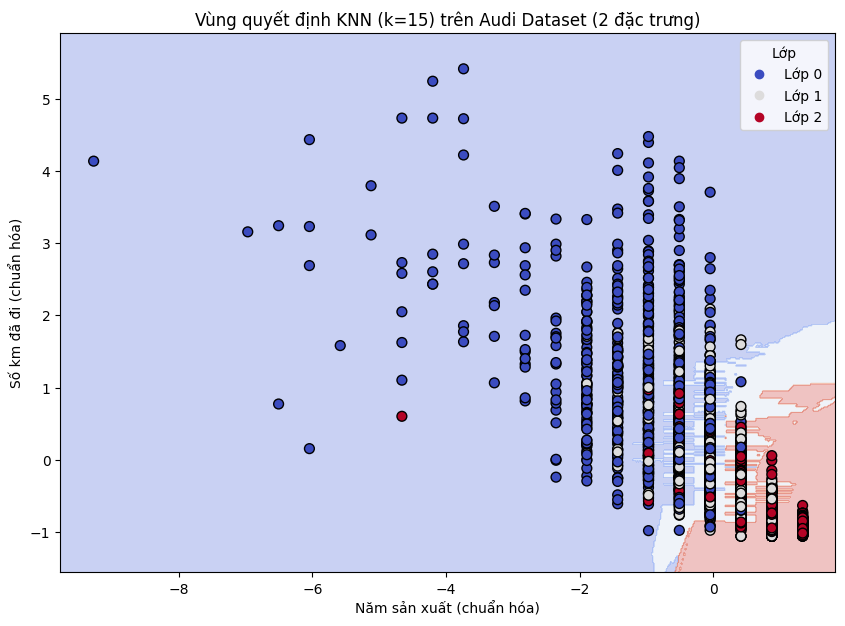

Độ chính xác KNN (k=15) trên 2 đặc trưng: 0.6420

--- Trực quan hóa OvR (Perceptron) (2 đặc trưng) ---


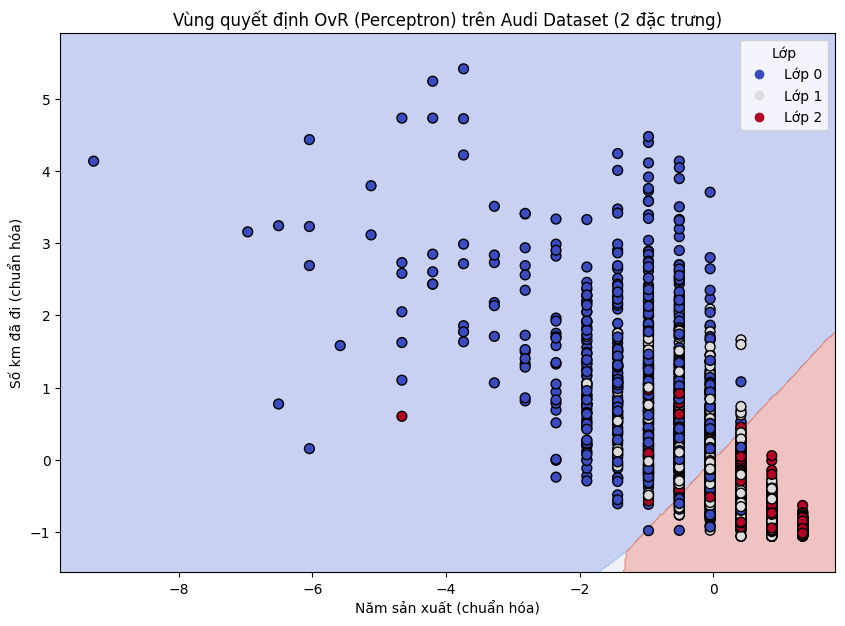

Độ chính xác OvR (Perceptron) trên 2 đặc trưng: 0.5961

--- Trực quan hóa OvO (Perceptron) (2 đặc trưng) ---


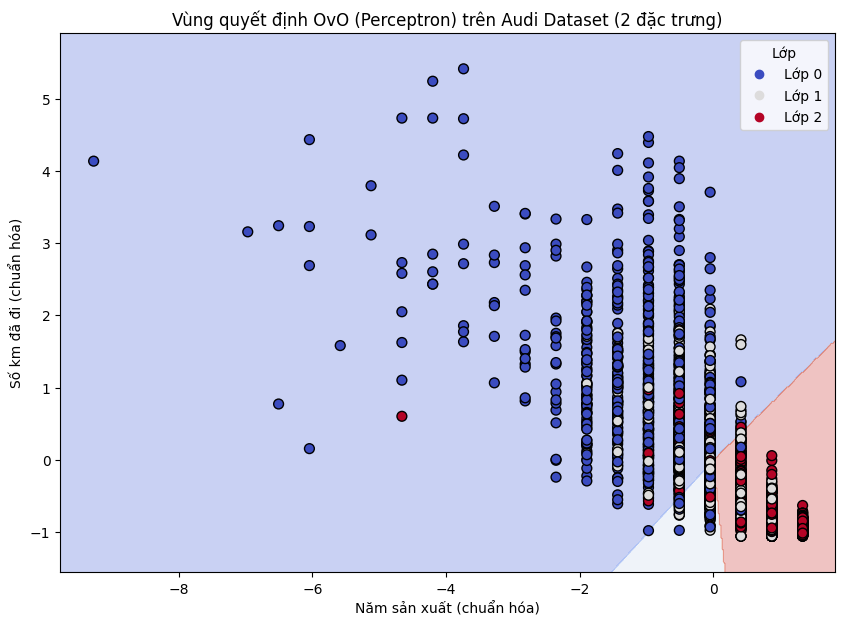

Độ chính xác OvO (Perceptron) trên 2 đặc trưng: 0.6361


In [33]:
if X_train_audi.size > 0 and X_test_audi.size > 0:
    # Chọn 2 đặc trưng đầu tiên: year (index 0) và mileage (index 1) sau khi chuẩn hóa
    X_train_2d_audi = X_train_audi[:, :2]
    X_test_2d_audi = X_test_audi[:, :2]

    # Hàm để vẽ vùng quyết định
    def plot_decision_regions(X, y, classifier, title, feature_names=['Đặc trưng 1 (chuẩn hóa)', 'Đặc trưng 2 (chuẩn hóa)']):
        plt.figure(figsize=(10, 7))
        
        # Tạo lưới điểm
        x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
        y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                             np.arange(y_min, y_max, 0.02))
        
        # Dự đoán trên lưới
        Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        
        # Vẽ contour và các điểm dữ liệu
        plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
        scatter = plt.scatter(X[:, 0], X[:, 1], c=y, s=50, edgecolor='k', cmap=plt.cm.coolwarm)
        
        plt.xlabel(feature_names[0])
        plt.ylabel(feature_names[1])
        plt.title(title)
        
        # Tạo legend cho các lớp
        handles, labels = scatter.legend_elements()
        # Lấy tên lớp từ np.unique(y) thay vì mặc định của legend_elements nếu cần
        class_labels = [f'Lớp {i}' for i in np.unique(y_target_audi)] # Giả sử y_target_audi có các lớp 0, 1, 2
        if len(handles) == len(class_labels):
             plt.legend(handles, class_labels, title="Lớp")
        else: # Fallback nếu số lượng handles không khớp (ví dụ: một lớp không có trong test set nhỏ)
            plt.legend(title="Lớp")

        plt.show()

    feature_pair_names = ['Năm sản xuất (chuẩn hóa)', 'Số km đã đi (chuẩn hóa)']

    # 5.1. Trực quan hóa KNN
    print("\n--- Trực quan hóa KNN (2 đặc trưng) ---")
    knn_2d_audi = KNNClassifier(k=15) # Có thể thử k khác cho 2D
    knn_2d_audi.fit(X_train_2d_audi, y_train_audi)
    plot_decision_regions(X_test_2d_audi, y_test_audi, knn_2d_audi, 
                          title='Vùng quyết định KNN (k=15) trên Audi Dataset (2 đặc trưng)', 
                          feature_names=feature_pair_names)
    y_pred_knn_2d_audi = knn_2d_audi.predict(X_test_2d_audi)
    accuracy_knn_2d_audi = calculate_accuracy(y_test_audi, y_pred_knn_2d_audi)
    print(f"Độ chính xác KNN (k=15) trên 2 đặc trưng: {accuracy_knn_2d_audi:.4f}")


    # 5.2. Trực quan hóa OvR (Perceptron)
    print("\n--- Trực quan hóa OvR (Perceptron) (2 đặc trưng) ---")
    ovr_2d_audi = OneVsRestClassifier(base_classifier_constructor=Perceptron, n_iters_perceptron=100)
    ovr_2d_audi.fit(X_train_2d_audi, y_train_audi)
    plot_decision_regions(X_test_2d_audi, y_test_audi, ovr_2d_audi, 
                          title='Vùng quyết định OvR (Perceptron) trên Audi Dataset (2 đặc trưng)',
                          feature_names=feature_pair_names)
    y_pred_ovr_2d_audi = ovr_2d_audi.predict(X_test_2d_audi)
    accuracy_ovr_2d_audi = calculate_accuracy(y_test_audi, y_pred_ovr_2d_audi)
    print(f"Độ chính xác OvR (Perceptron) trên 2 đặc trưng: {accuracy_ovr_2d_audi:.4f}")


    # 5.3. Trực quan hóa OvO (Perceptron)
    print("\n--- Trực quan hóa OvO (Perceptron) (2 đặc trưng) ---")
    ovo_2d_audi = OneVsOneClassifier(base_classifier_constructor=Perceptron, n_iters_perceptron=100)
    ovo_2d_audi.fit(X_train_2d_audi, y_train_audi)
    plot_decision_regions(X_test_2d_audi, y_test_audi, ovo_2d_audi, 
                          title='Vùng quyết định OvO (Perceptron) trên Audi Dataset (2 đặc trưng)',
                          feature_names=feature_pair_names)
    y_pred_ovo_2d_audi = ovo_2d_audi.predict(X_test_2d_audi)
    accuracy_ovo_2d_audi = calculate_accuracy(y_test_audi, y_pred_ovo_2d_audi)
    print(f"Độ chính xác OvO (Perceptron) trên 2 đặc trưng: {accuracy_ovo_2d_audi:.4f}")
    
else:
    print("Không thể thực hiện trực quan hóa do lỗi tải hoặc xử lý dữ liệu.")

## 6. Nhận xét và Kết luận

-   Phần trực quan hóa đã được thêm vào, sử dụng 2 đặc trưng (`year` và `mileage` sau khi chuẩn hóa) để vẽ các vùng quyết định cho KNN, OvR (Perceptron), và OvO (Perceptron) trên tập kiểm thử.

-   Các biểu đồ scatter cho thấy cách mỗi mô hình phân chia không gian đặc trưng 2D thành các vùng tương ứng với 3 lớp giá xe ("Thấp", "Trung bình", "Cao").

-   **Độ chính xác trên 2 đặc trưng:** Việc giảm số chiều từ 3 xuống 2 đặc trưng để trực quan hóa có thể làm thay đổi độ chính xác của các mô hình. Thông thường, sử dụng nhiều đặc trưng hơn (nếu chúng mang thông tin hữu ích) sẽ cho kết quả tốt hơn.

-   **Giới hạn của Perceptron:** Như đã đề cập, vì Perceptron là bộ phân loại tuyến tính, các vùng quyết định của OvR và OvO sẽ được tạo thành từ các đường thẳng (trong không gian 2D của Perceptron cơ sở). Nếu các lớp không phân tách tuyến tính tốt, hiệu suất sẽ bị hạn chế.

-   **KNN:** Vùng quyết định của KNN thường phức tạp hơn và bám sát theo sự phân bố của các điểm dữ liệu huấn luyện. Giá trị $k$ lớn hơn (ví dụ $k=15$ được dùng cho trực quan hóa) thường tạo ra các đường biên mượt mà hơn.